In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# 결과 저장용 폴더 생성
!mkdir -p /content/drive/MyDrive/BackdoorBench_results

Mounted at /content/drive


In [ ]:
#방어
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!nvidia-smi

Sun May 10 02:48:11 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!git clone https://github.com/SCLBD/BackdoorBench.git
%cd BackdoorBench
!sh ./sh/init_folders.sh

Cloning into 'BackdoorBench'...
remote: Enumerating objects: 5593, done.
remote: Counting objects: 100% (917/917), done.
remote: Compressing objects: 100% (242/242), done.
remote: Total 5593 (delta 780), reused 675 (delta 675), pack-reused 4676 (from 1)
Receiving objects: 100% (5593/5593), 75.61 MiB | 11.56 MiB/s, done.
Resolving deltas: 100% (3021/3021), done.
/content/BackdoorBench
mkdir: cannot create directory ‘record’: File exists


In [ ]:
#방어
%cd /content
!git clone https://github.com/SCLBD/BackdoorBench.git
%cd BackdoorBench
!sh ./sh/init_folders.sh

/content
Cloning into 'BackdoorBench'...
remote: Enumerating objects: 5593, done.
remote: Counting objects: 100% (915/915), done.
remote: Compressing objects: 100% (223/223), done.
remote: Total 5593 (delta 785), reused 692 (delta 692), pack-reused 4678 (from 1)
Receiving objects: 100% (5593/5593), 75.61 MiB | 29.07 MiB/s, done.
Resolving deltas: 100% (3022/3022), done.
/content/BackdoorBench
mkdir: cannot create directory ‘record’: File exists


In [ ]:
# 예시: 파이썬 버전 체크를 무시하도록 수정했다면 실행
!bash install.sh

bash: install.sh: No such file or directory


In [ ]:
def backup_to_drive():
    import shutil
    shutil.copytree('./record', '/content/drive/MyDrive/BackdoorBench_results/record',
                    dirs_exist_ok=True)
    print("Drive 백업 완료!")

In [ ]:
!pip install opencv-python pandas Pillow scikit-learn scikit-image tqdm pyyaml \
    tensorboard kornia imageio matplotlib scipy seaborn \
    shap grad-cam plotly umap-learn graphviz hiddenlayer \
    PyHessian "torchmetrics[image]"

!pip install pytorch-wavelets
!pip install -U git+https://github.com/szagoruyko/pytorchviz.git@master

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 98.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 61.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 125.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 70.7 MB/s eta 0:00:00
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=4e55cf7668818cc0e2213a9183e39be300bdeab3be3059efc7ab3e258df18568
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 5.2 MB/s eta 0:00:00
  Cloning https://github.com/szagoruyko/pytorchviz.git (to revision master) to /tmp/pip-req-build-gpqmm9

In [ ]:
import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch: 2.10.0+cu128
CUDA: True
GPU: Tesla T4


In [ ]:
!sed -i 's/torch.load(save_path)/torch.load(save_path, weights_only=False)/g' ./utils/save_load_attack.py
!sed -i 's/torch.load(load_path)/torch.load(load_path, weights_only=False)/g' ./utils/save_load_attack.py

# NumPy 2.0+: np.infty → np.inf 패치
!sed -i 's/np.infty/np.inf/g' ./utils/trainer_cls.py

In [ ]:
!python ./attack/badnet.py \
    --yaml_path ./config/attack/prototype/cifar10.yaml \
    --patch_mask_path ./resource/badnet/trigger_image.png \
    --save_folder_name badnet_0_1

# 공격 완료 후 Drive 백업
backup_to_drive()

INFO:root:{'amp': False,
 'attack': 'badnet',
 'attack_label_trans': 'all2one',
 'attack_target': 0,
 'batch_size': 128,
 'bd_yaml_path': './config/attack/badnet/default.yaml',
 'client_optimizer': 'sgd',
 'dataset': 'cifar10',
 'dataset_path': './data/cifar10',
 'device': 'cuda:0',
 'epochs': 100,
 'frequency_save': 0,
 'img_size': (32, 32, 3),
 'input_channel': 3,
 'input_height': 32,
 'input_width': 32,
 'lr': 0.01,
 'lr_scheduler': 'CosineAnnealingLR',
 'model': 'preactresnet18',
 'non_blocking': True,
 'num_classes': 10,
 'num_workers': 4,
 'patch_mask_path': './resource/badnet/trigger_image.png',
 'pin_memory': True,
 'pratio': 0.1,
 'prefetch': False,
 'random_seed': 0,
 'save_folder_name': 'badnet_0_1',
 'save_path': './record/badnet_0_1',
 'sgd_momentum': 0.9,
 'terminal_info': ['./attack/badnet.py',
                   '--yaml_path',
                   './config/attack/prototype/cifar10.yaml',
                   '--patch_mask_path',
                   './resource/badnet/trigge

In [ ]:
import torch
# PyTorch 2.6+에서는 weights_only=False 필수
result = torch.load('./record/badnet_0_1/attack_result.pt', map_location='cpu', weights_only=False)
print(result.keys())

dict_keys(['model_name', 'num_classes', 'model', 'data_path', 'img_size', 'clean_data', 'bd_train', 'bd_test'])


In [ ]:
print(f"모델: {result['model_name']}")
print(f"클래스 수: {result['num_classes']}")
print(f"이미지 크기: {result['img_size']}")
print(f"백도어 학습 데이터 수: {len(result['bd_train'])}")
print(f"백도어 테스트 데이터 수: {len(result['bd_test'])}")

모델: preactresnet18
클래스 수: 10
이미지 크기: (32, 32, 3)
백도어 학습 데이터 수: 6
백도어 테스트 데이터 수: 6


In [ ]:
import pandas as pd

# 최종 요약 결과
print("=" * 50)
print("[ 최종 결과 요약 ]")
print("=" * 50)
summary = pd.read_csv('./record/badnet_0_1/attack_df_summary.csv')
print(summary.to_string(index=False))

# epoch별 학습 로그에서 핵심 지표만 추출
print("\n" + "=" * 50)
print("[ Epoch별 핵심 지표 ]")
print("=" * 50)
df = pd.read_csv('./record/badnet_0_1/attack_df.csv')
cols = [c for c in ['epoch', 'train_acc', 'test_acc', 'test_asr', 'test_ra',
                     'train_epoch_loss_avg_over_batch'] if c in df.columns]
print(df[cols].to_string(index=False))

# 최종 epoch 결과만 따로 출력
last = df.iloc[-1]
print("\n" + "=" * 50)
print("[ 최종 Epoch 결과 ]")
print("=" * 50)
for col in cols:
    print(f"  {col:40s}: {last[col]}")

[ 최종 결과 요약 ]
     Unnamed: 0 epoch batch train_epoch_loss_avg_over_batch          train_acc train_acc_clean_only  train_asr_bd_only   train_ra_bd_only clean_test_loss_avg_over_batch bd_test_loss_avg_over_batch test_acc           test_asr             test_ra
           last    99   390             0.03516032729560557 0.9891626602564103   0.9986423627339699 0.9037883343355382 0.1936259771497294            0.42797857296617725         0.28491322772288824   0.9173              0.944 0.05366666666666667
      valid_max    99   390              1.5852601876625647 0.9896634615384615   0.9986423627339699 0.9112935522627152 0.6244987971130713             1.3525674675084367          1.9981135314619038   0.9197 0.9698888888888889  0.5923333333333334
exist_nan_value False False                           False              False                False              False              False                          False                       False    False              False               False

[ Epoc

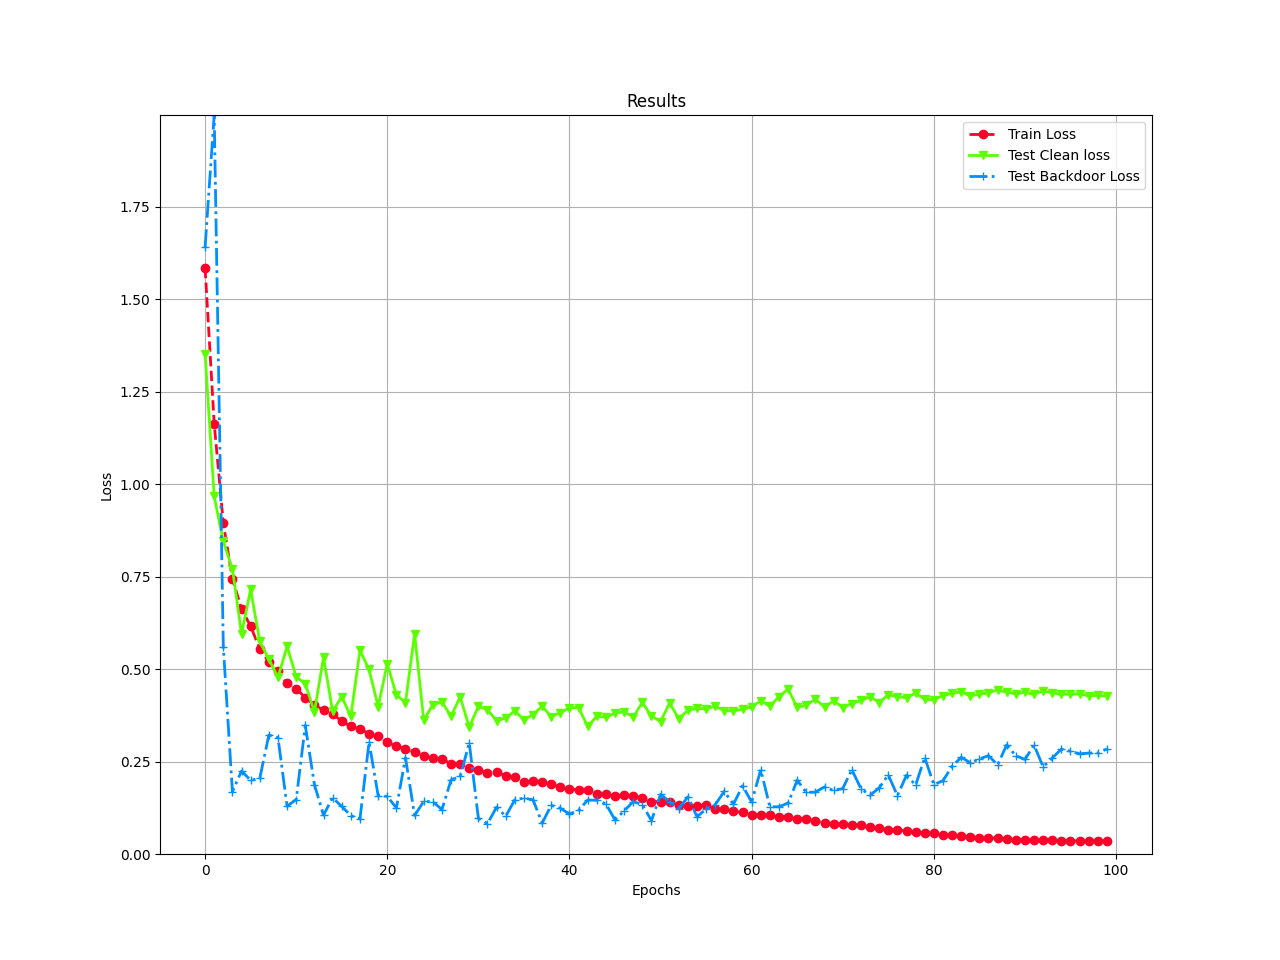

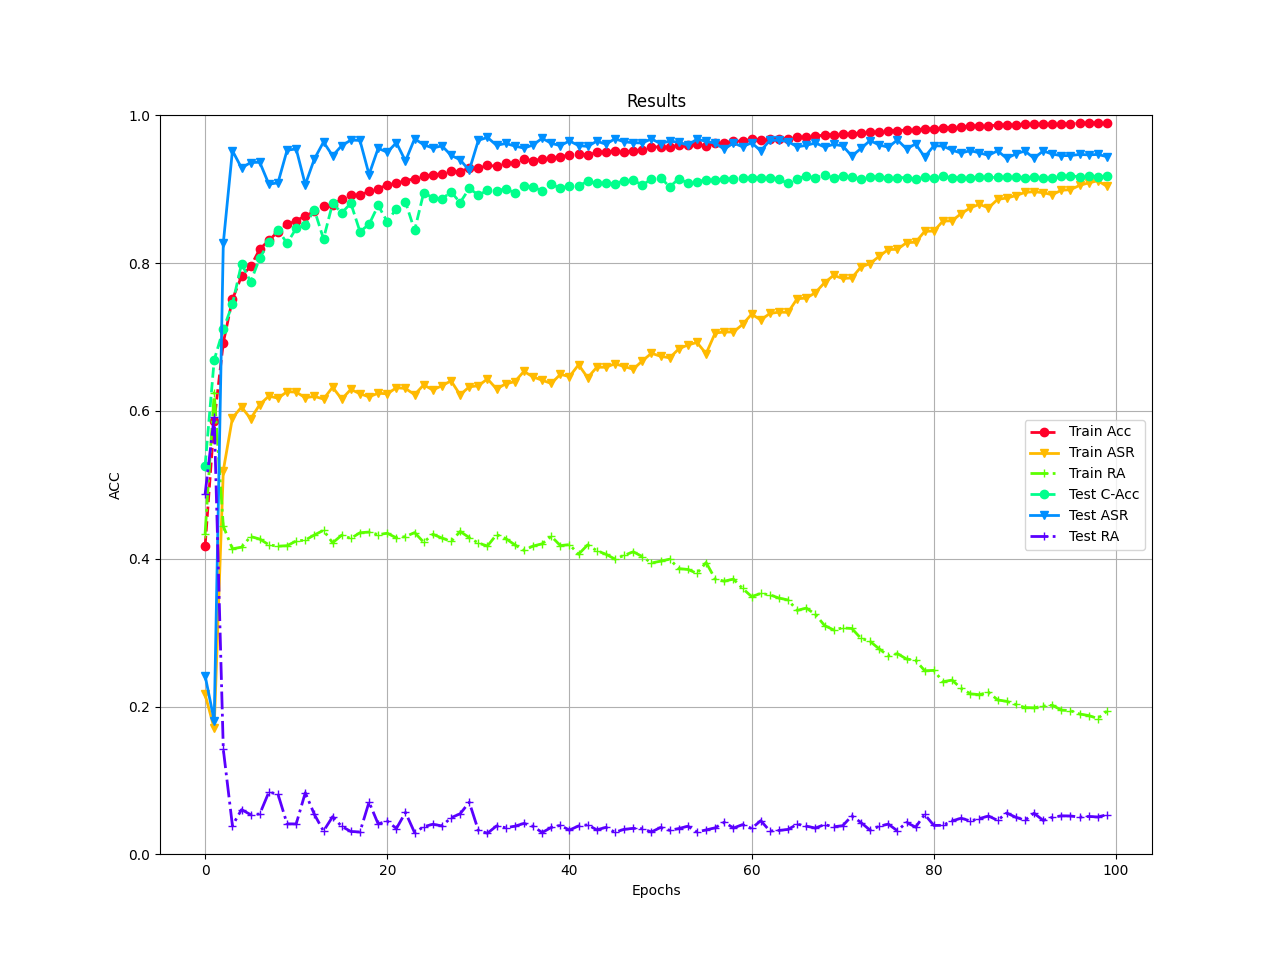

In [ ]:
from IPython.display import Image, display

# 손실 그래프
display(Image('./record/badnet_0_1/loss_metric_plots.png'))

# 정확도 그래프
display(Image('./record/badnet_0_1/acc_like_metric_plots.png'))

In [ ]:
%cd /content/BackdoorBench

[Errno 2] No such file or directory: '/content/BackdoorBench'
/content


In [ ]:
# 주의: 띄어쓰기가 있는 이름이라면 이름 전체를 따옴표("")로 감싸주세요.
!cp -r "/content/drive/MyDrive/BackdoorBench_results/record/badnet_0_1" ./record/
# 복사가 잘 되었는지 확인
!ls ./record/

badnet_0_1  readme.md


In [ ]:
!du -sh ./record/

102M	./record/


In [ ]:
!sed -i 's/torch.load(save_path)/torch.load(save_path, weights_only=False)/g' /content/BackdoorBench/utils/save_load_attack.py

In [ ]:
!find /content/BackdoorBench -type f -name "*.py" -exec sed -i 's/np.infty/np.inf/g' {} +

In [ ]:
!python ./defense/abl.py \
    --result_file badnet_0_1 \
    --yaml_path ./config/defense/abl/cifar10.yaml \
    --dataset cifar10

100% 170M/170M [00:03<00:00, 49.2MB/s]
loading...
loading...
INFO:root:{'amp': True,
 'batch_size': 256,
 'checkpoint_load': None,
 'checkpoint_save': 'record/badnet_0_1/defense/abl/checkpoint/',
 'client_optimizer': 'sgd',
 'dataset': 'cifar10',
 'dataset_path': './data/cifar10',
 'device': 'cuda',
 'epochs': 100,
 'finetuning_ascent_model': True,
 'finetuning_epochs': 60,
 'flooding': 0.5,
 'frequency_save': 0,
 'gamma': 0.5,
 'gradient_ascent_type': 'Flooding',
 'img_size': (32, 32, 3),
 'input_channel': 3,
 'input_height': 32,
 'input_width': 32,
 'isolation_ratio': 0.01,
 'log': 'record/badnet_0_1/defense/abl/log/',
 'lr': 0.01,
 'lr_finetuning_init': 0.1,
 'lr_scheduler': 'CosineAnnealingLR',
 'lr_unlearning_init': 0.0005,
 'model': 'preactresnet18',
 'momentum': 0.9,
 'non_blocking': True,
 'num_classes': 10,
 'num_workers': 4,
 'pin_memory': True,
 'prefetch': False,
 'random_seed': 0,
 'result_file': 'badnet_0_1',
 'save_path': 'record/badnet_0_1/defense/abl/',
 'sgd_momentum'

In [ ]:
!python ./defense/fp.py \
    --result_file badnet_0_1 \
    --yaml_path ./config/defense/fp/cifar10.yaml \
    --dataset cifar10

2026-05-10:16:40:06 [INFO    ] [fp.py:202] {'acc_ratio': 0.1,
 'amp': True,
 'batch_size': 256,
 'client_optimizer': 'sgd',
 'dataset': 'cifar10',
 'dataset_path': 'data//cifar10',
 'defense_save_path': 'record/badnet_0_1/defense/fp',
 'device': 'cuda',
 'epochs': 100,
 'frequency_save': 0,
 'img_size': (32, 32, 3),
 'index': None,
 'input_channel': 3,
 'input_height': 32,
 'input_width': 32,
 'lr': 0.01,
 'lr_scheduler': 'CosineAnnealingLR',
 'model': 'preactresnet18',
 'non_blocking': True,
 'num_classes': 10,
 'num_workers': 4,
 'once_prune_ratio': 0.01,
 'pin_memory': True,
 'poison_rate': 0.1,
 'prefetch': False,
 'random_seed': 0,
 'ratio': 0.05,
 'result_file': 'badnet_0_1',
 'sgd_momentum': 0.9,
 'target_label': 0,
 'target_type': 'all2one',
 'terminal_info': ['./defense/fp.py',
                   '--result_file',
                   'badnet_0_1',
                   '--yaml_path',
                   './config/defense/fp/cifar10.yaml',
                   '--dataset',
            

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# 2. BackdoorBench 다시 클론 및 폴더 이동
%cd /content
!git clone https://github.com/SCLBD/BackdoorBench.git
%cd /content/BackdoorBench


Mounted at /content/drive
/content
Cloning into 'BackdoorBench'...
remote: Enumerating objects: 5593, done.
remote: Counting objects: 100% (917/917), done.
remote: Compressing objects: 100% (242/242), done.
remote: Total 5593 (delta 780), reused 675 (delta 675), pack-reused 4676 (from 1)
Receiving objects: 100% (5593/5593), 75.61 MiB | 17.87 MiB/s, done.
Resolving deltas: 100% (3021/3021), done.
/content/BackdoorBench


In [ ]:
!mkdir -p record

# 4. 드라이브의 BackdoorBench_results 안의 내용물들을 record 폴더로 모두 복사
!cp -r /content/drive/MyDrive/BackdoorBench_results/* ./record/

# 5. 복사가 잘 되었는지 확인 (어떤 폴더들이 복사되었는지 리스트 출력)
!ls ./record/

readme.md  record


In [ ]:
!ls -l ./record/

total 12
drwxr-xr-x 3 root root 4096 May 23 04:03 badnet_demo
-rw-r--r-- 1 root root  460 May 23 03:50 readme.md
drwx------ 3 root root 4096 May 23 03:55 record


In [ ]:
!find ./record -name "attack_result.pt"

./record/record/badnet_0_1/attack_result.pt


In [ ]:
# 안쪽에 숨겨진 record 폴더 안의 내용물(badnet_0_1 폴더)을 바깥 정상 위치로 꺼내기
!mv ./record/record/* ./record/

# 빈 껍데기가 된 안쪽 record 폴더 삭제
!rm -r ./record/record/

# 제대로 꺼내졌는지 확인 (badnet_0_1 폴더가 보여야 합니다)
!ls -l ./record/

total 12
drwx------ 4 root root 4096 May 23 03:57 badnet_0_1
drwxr-xr-x 3 root root 4096 May 23 04:03 badnet_demo
-rw------- 1 root root  460 May 23 03:55 readme.md


In [ ]:
file_path = '/content/BackdoorBench/utils/save_load_attack.py'

with open(file_path, 'r') as f:
    code_lines = f.read()

# PyTorch 2.6 정책에 맞춰 weights_only=False 옵션 강제 추가
code_lines = code_lines.replace('torch.load(save_path)', 'torch.load(save_path, weights_only=False)')

with open(file_path, 'w') as f:
    f.write(code_lines)

print("✅ 코드 패치 완료! 이제 방어 기법을 다시 실행해 보세요.")

✅ 코드 패치 완료! 이제 방어 기법을 다시 실행해 보세요.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 1) 현재 위치 기준 record 폴더 찾기
!find /content -type d -name "defense" 2>/dev/null
!find /content -name "defense_result.pt" 2>/dev/null


In [ ]:
import os
print("현재 위치:", os.getcwd())
!find /content -name "defense_result.pt" 2>/dev/null
!find /content -type d -name "defense" 2>/dev/null


현재 위치: /content


In [ ]:
# 방어 결과 .pt 파일만 찾기 (이미지는 안 나옴)
!find ./record/badnet_0_1/defense -name "*.pt" 2>/dev/null


In [ ]:
!python defense/ft.py --result_file badnet_0_1

100% 170M/170M [00:13<00:00, 12.3MB/s]
loading...
loading...
INFO:root:{'amp': True,
 'batch_size': 256,
 'checkpoint_load': None,
 'checkpoint_save': 'record/badnet_0_1/defense/ft/checkpoint/',
 'client_optimizer': 'sgd',
 'dataset': 'cifar10',
 'dataset_path': './data/cifar10',
 'device': 'cuda',
 'epochs': 100,
 'frequency_save': 0,
 'img_size': (32, 32, 3),
 'index': None,
 'input_channel': 3,
 'input_height': 32,
 'input_width': 32,
 'log': 'record/badnet_0_1/defense/ft/log/',
 'lr': 0.01,
 'lr_scheduler': 'CosineAnnealingLR',
 'model': 'preactresnet18',
 'non_blocking': True,
 'num_classes': 10,
 'num_workers': 4,
 'pin_memory': True,
 'prefetch': False,
 'random_seed': 0,
 'ratio': 0.05,
 'result_file': 'badnet_0_1',
 'save_path': 'record/badnet_0_1/defense/ft/',
 'sgd_momentum': 0.9,
 'terminal_info': ['defense/ft.py', '--result_file', 'badnet_0_1'],
 'wd': 0.0005,
 'yaml_path': './config/defense/ft/config.yaml'}
2026-05-23:04:10:40 [INFO    ] [ft.py:170] {'amp': True,
 'batch_

In [ ]:
!python defense/nad.py --result_file badnet_0_1

loading...
loading...
INFO:root:{'amp': True,
 'batch_size': 256,
 'beta1': 500,
 'beta2': 1000,
 'beta3': 1000,
 'checkpoint_load': None,
 'checkpoint_save': 'record/badnet_0_1/defense/nad/checkpoint/',
 'client_optimizer': 'sgd',
 'dataset': 'cifar10',
 'dataset_path': './data/cifar10',
 'device': 'cuda',
 'epochs': 100,
 'frequency_save': 0,
 'img_size': (32, 32, 3),
 'index': None,
 'input_channel': 3,
 'input_height': 32,
 'input_width': 32,
 'log': 'record/badnet_0_1/defense/nad/log/',
 'lr': 0.01,
 'lr_scheduler': 'CosineAnnealingLR',
 'model': 'preactresnet18',
 'momentum': 0.9,
 'non_blocking': True,
 'num_classes': 10,
 'num_workers': 4,
 'p': 2.0,
 'pin_memory': True,
 'prefetch': False,
 'random_seed': 0,
 'ratio': 0.05,
 'result_file': 'badnet_0_1',
 'save_path': 'record/badnet_0_1/defense/nad/',
 'sgd_momentum': 0.9,
 'te_epochs': 10,
 'teacher_model_loc': None,
 'terminal_info': ['defense/nad.py', '--result_file', 'badnet_0_1'],
 'wd': 0.0005,
 'weight_decay': 0.0001,
 '

In [ ]:
!python defense/anp.py --result_file badnet_0_1

/content/BackdoorBench/defense/anp.py:266: SyntaxWarning: invalid escape sequence '\s'
  tempt = pd.read_csv(file_name, sep='\s+', skiprows=1, header=None)
loading...
loading...
INFO:root:{'acc_ratio': 0.1,
 'amp': False,
 'anp_alpha': 0.2,
 'anp_eps': 0.4,
 'anp_steps': 1,
 'batch_size': 256,
 'checkpoint_load': None,
 'checkpoint_save': 'record/badnet_0_1/defense/anp/checkpoint/',
 'client_optimizer': 'sgd',
 'dataset': 'cifar10',
 'dataset_path': './data/cifar10',
 'device': 'cuda',
 'epochs': 100,
 'frequency_save': 0,
 'img_size': (32, 32, 3),
 'index': None,
 'input_channel': 3,
 'input_height': 32,
 'input_width': 32,
 'log': 'record/badnet_0_1/defense/anp/log/',
 'lr': 0.01,
 'lr_scheduler': 'CosineAnnealingLR',
 'model': 'preactresnet18',
 'nb_iter': 2000,
 'non_blocking': True,
 'num_classes': 10,
 'num_workers': 4,
 'pin_memory': True,
 'prefetch': False,
 'print_every': 500,
 'pruning_by': 'threshold',
 'pruning_max': 0.9,
 'pruning_step': 0.05,
 'random_seed': 0,
 'ratio':

In [ ]:
!python defense/nc.py --result_file badnet_0_1

loading...
loading...
INFO:root:{'EPSILON': 1e-07,
 'amp': True,
 'atk_succ_threshold': 98.0,
 'batch_size': 256,
 'checkpoint_load': None,
 'checkpoint_save': 'record/badnet_0_1/defense/nc/checkpoint/',
 'cleaning_ratio': 0.05,
 'client_optimizer': 'sgd',
 'cost_multiplier': 2,
 'dataset': 'cifar10',
 'dataset_path': './data/cifar10',
 'device': 'cuda',
 'early_stop': True,
 'early_stop_patience': 25,
 'early_stop_threshold': 0.99,
 'epochs': 100,
 'frequency_save': 0,
 'img_size': (32, 32, 3),
 'index': None,
 'init_cost': 0.001,
 'input_channel': 3,
 'input_height': 32,
 'input_width': 32,
 'log': 'record/badnet_0_1/defense/nc/log/',
 'lr': 0.01,
 'lr_scheduler': 'CosineAnnealingLR',
 'mask_lr': 0.1,
 'model': 'preactresnet18',
 'n_times_test': 1,
 'nc_epoch': 80,
 'non_blocking': True,
 'num_classes': 10,
 'num_workers': 4,
 'patience': 5,
 'pin_memory': True,
 'prefetch': False,
 'random_seed': 0,
 'ratio': 0.05,
 'result_file': 'badnet_0_1',
 'save_path': 'record/badnet_0_1/defen

In [ ]:
%cd /content
!git clone https://github.com/SCLBD/BackdoorBench.git
%cd /content/BackdoorBench
!sh ./sh/init_folders.sh

/content
Cloning into 'BackdoorBench'...
remote: Enumerating objects: 5593, done.
remote: Counting objects: 100% (915/915), done.
remote: Compressing objects: 100% (223/223), done.
remote: Total 5593 (delta 785), reused 692 (delta 692), pack-reused 4678 (from 1)
Receiving objects: 100% (5593/5593), 75.61 MiB | 23.01 MiB/s, done.
Resolving deltas: 100% (3022/3022), done.
/content/BackdoorBench
mkdir: cannot create directory ‘record’: File exists


In [ ]:
# 패치1: PyTorch 2.6+
!sed -i 's/torch.load(save_path)/torch.load(save_path, weights_only=False)/g' /content/BackdoorBench/utils/save_load_attack.py
!sed -i 's/torch.load(load_path)/torch.load(load_path, weights_only=False)/g' /content/BackdoorBench/utils/save_load_attack.py

# 패치2: NumPy 2.0+ (ANP가 죽었던 원인)
!find /content/BackdoorBench -type f -name "*.py" -exec sed -i 's/np.infty/np.inf/g' {} +

# 확인 — 0 이 나와야 정상
!grep -rn "np.infty" /content/BackdoorBench --include=*.py | wc -l


0


In [ ]:
!cp -r "/content/drive/MyDrive/BackdoorBench_results/record/badnet_0_1" /content/BackdoorBench/record/
!ls -l /content/BackdoorBench/record/badnet_0_1/attack_result.pt


-rw------- 1 root root 47847739 May 31 01:06 /content/BackdoorBench/record/badnet_0_1/attack_result.pt


In [ ]:
# 1. ABL
!python ./defense/abl.py --result_file badnet_0_1 --yaml_path ./config/defense/abl/cifar10.yaml --dataset cifar10


loading...
loading...
INFO:root:{'amp': True,
 'batch_size': 256,
 'checkpoint_load': None,
 'checkpoint_save': 'record/badnet_0_1/defense/abl/checkpoint/',
 'client_optimizer': 'sgd',
 'dataset': 'cifar10',
 'dataset_path': './data/cifar10',
 'device': 'cuda',
 'epochs': 100,
 'finetuning_ascent_model': True,
 'finetuning_epochs': 60,
 'flooding': 0.5,
 'frequency_save': 0,
 'gamma': 0.5,
 'gradient_ascent_type': 'Flooding',
 'img_size': (32, 32, 3),
 'input_channel': 3,
 'input_height': 32,
 'input_width': 32,
 'isolation_ratio': 0.01,
 'log': 'record/badnet_0_1/defense/abl/log/',
 'lr': 0.01,
 'lr_finetuning_init': 0.1,
 'lr_scheduler': 'CosineAnnealingLR',
 'lr_unlearning_init': 0.0005,
 'model': 'preactresnet18',
 'momentum': 0.9,
 'non_blocking': True,
 'num_classes': 10,
 'num_workers': 4,
 'pin_memory': True,
 'prefetch': False,
 'random_seed': 0,
 'result_file': 'badnet_0_1',
 'save_path': 'record/badnet_0_1/defense/abl/',
 'sgd_momentum': 0.9,
 'terminal_info': ['./defense/ab

In [ ]:
import shutil
shutil.copytree('/content/BackdoorBench/record', '/content/drive/MyDrive/BackdoorBench_results/record', dirs_exist_ok=True)
print("백업 완료")

백업 완료


In [ ]:
# 2. FP
!python ./defense/fp.py --result_file badnet_0_1 --yaml_path ./config/defense/fp/cifar10.yaml --dataset cifar10


2026-05-31:01:12:16 [INFO    ] [fp.py:202] {'acc_ratio': 0.1,
 'amp': True,
 'batch_size': 256,
 'client_optimizer': 'sgd',
 'dataset': 'cifar10',
 'dataset_path': 'data//cifar10',
 'defense_save_path': 'record/badnet_0_1/defense/fp',
 'device': 'cuda',
 'epochs': 100,
 'frequency_save': 0,
 'img_size': (32, 32, 3),
 'index': None,
 'input_channel': 3,
 'input_height': 32,
 'input_width': 32,
 'lr': 0.01,
 'lr_scheduler': 'CosineAnnealingLR',
 'model': 'preactresnet18',
 'non_blocking': True,
 'num_classes': 10,
 'num_workers': 4,
 'once_prune_ratio': 0.01,
 'pin_memory': True,
 'poison_rate': 0.1,
 'prefetch': False,
 'random_seed': 0,
 'ratio': 0.05,
 'result_file': 'badnet_0_1',
 'sgd_momentum': 0.9,
 'target_label': 0,
 'target_type': 'all2one',
 'terminal_info': ['./defense/fp.py',
                   '--result_file',
                   'badnet_0_1',
                   '--yaml_path',
                   './config/defense/fp/cifar10.yaml',
                   '--dataset',
            

In [ ]:
import shutil
shutil.copytree('/content/BackdoorBench/record', '/content/drive/MyDrive/BackdoorBench_results/record', dirs_exist_ok=True)
print("백업 완료")

백업 완료


In [9]:
# 3. FT
!python defense/ft.py --result_file badnet_0_1


loading...
loading...
INFO:root:{'amp': True,
 'batch_size': 256,
 'checkpoint_load': None,
 'checkpoint_save': 'record/badnet_0_1/defense/ft/checkpoint/',
 'client_optimizer': 'sgd',
 'dataset': 'cifar10',
 'dataset_path': './data/cifar10',
 'device': 'cuda',
 'epochs': 100,
 'frequency_save': 0,
 'img_size': (32, 32, 3),
 'index': None,
 'input_channel': 3,
 'input_height': 32,
 'input_width': 32,
 'log': 'record/badnet_0_1/defense/ft/log/',
 'lr': 0.01,
 'lr_scheduler': 'CosineAnnealingLR',
 'model': 'preactresnet18',
 'non_blocking': True,
 'num_classes': 10,
 'num_workers': 4,
 'pin_memory': True,
 'prefetch': False,
 'random_seed': 0,
 'ratio': 0.05,
 'result_file': 'badnet_0_1',
 'save_path': 'record/badnet_0_1/defense/ft/',
 'sgd_momentum': 0.9,
 'terminal_info': ['defense/ft.py', '--result_file', 'badnet_0_1'],
 'wd': 0.0005,
 'yaml_path': './config/defense/ft/config.yaml'}
2026-05-31:01:54:56 [INFO    ] [ft.py:170] {'amp': True,
 'batch_size': 256,
 'checkpoint_load': None,
 

In [10]:
import shutil
shutil.copytree('/content/BackdoorBench/record', '/content/drive/MyDrive/BackdoorBench_results/record', dirs_exist_ok=True)
print("백업 완료")

백업 완료


In [11]:
# 4. NAD
!python defense/nad.py --result_file badnet_0_1


loading...
loading...
INFO:root:{'amp': True,
 'batch_size': 256,
 'beta1': 500,
 'beta2': 1000,
 'beta3': 1000,
 'checkpoint_load': None,
 'checkpoint_save': 'record/badnet_0_1/defense/nad/checkpoint/',
 'client_optimizer': 'sgd',
 'dataset': 'cifar10',
 'dataset_path': './data/cifar10',
 'device': 'cuda',
 'epochs': 100,
 'frequency_save': 0,
 'img_size': (32, 32, 3),
 'index': None,
 'input_channel': 3,
 'input_height': 32,
 'input_width': 32,
 'log': 'record/badnet_0_1/defense/nad/log/',
 'lr': 0.01,
 'lr_scheduler': 'CosineAnnealingLR',
 'model': 'preactresnet18',
 'momentum': 0.9,
 'non_blocking': True,
 'num_classes': 10,
 'num_workers': 4,
 'p': 2.0,
 'pin_memory': True,
 'prefetch': False,
 'random_seed': 0,
 'ratio': 0.05,
 'result_file': 'badnet_0_1',
 'save_path': 'record/badnet_0_1/defense/nad/',
 'sgd_momentum': 0.9,
 'te_epochs': 10,
 'teacher_model_loc': None,
 'terminal_info': ['defense/nad.py', '--result_file', 'badnet_0_1'],
 'wd': 0.0005,
 'weight_decay': 0.0001,
 '

In [12]:
import shutil
shutil.copytree('/content/BackdoorBench/record', '/content/drive/MyDrive/BackdoorBench_results/record', dirs_exist_ok=True)
print("백업 완료")

백업 완료


In [13]:
# 5. ANP (이번엔 패치돼서 안 죽음)
!python defense/anp.py --result_file badnet_0_1


/content/BackdoorBench/defense/anp.py:266: SyntaxWarning: invalid escape sequence '\s'
  tempt = pd.read_csv(file_name, sep='\s+', skiprows=1, header=None)
loading...
loading...
INFO:root:{'acc_ratio': 0.1,
 'amp': False,
 'anp_alpha': 0.2,
 'anp_eps': 0.4,
 'anp_steps': 1,
 'batch_size': 256,
 'checkpoint_load': None,
 'checkpoint_save': 'record/badnet_0_1/defense/anp/checkpoint/',
 'client_optimizer': 'sgd',
 'dataset': 'cifar10',
 'dataset_path': './data/cifar10',
 'device': 'cuda',
 'epochs': 100,
 'frequency_save': 0,
 'img_size': (32, 32, 3),
 'index': None,
 'input_channel': 3,
 'input_height': 32,
 'input_width': 32,
 'log': 'record/badnet_0_1/defense/anp/log/',
 'lr': 0.01,
 'lr_scheduler': 'CosineAnnealingLR',
 'model': 'preactresnet18',
 'nb_iter': 2000,
 'non_blocking': True,
 'num_classes': 10,
 'num_workers': 4,
 'pin_memory': True,
 'prefetch': False,
 'print_every': 500,
 'pruning_by': 'threshold',
 'pruning_max': 0.9,
 'pruning_step': 0.05,
 'random_seed': 0,
 'ratio':

In [14]:
import shutil
shutil.copytree('/content/BackdoorBench/record', '/content/drive/MyDrive/BackdoorBench_results/record', dirs_exist_ok=True)
print("백업 완료")

백업 완료


In [15]:
# 6. NC
!python defense/nc.py --result_file badnet_0_1


loading...
loading...
INFO:root:{'EPSILON': 1e-07,
 'amp': True,
 'atk_succ_threshold': 98.0,
 'batch_size': 256,
 'checkpoint_load': None,
 'checkpoint_save': 'record/badnet_0_1/defense/nc/checkpoint/',
 'cleaning_ratio': 0.05,
 'client_optimizer': 'sgd',
 'cost_multiplier': 2,
 'dataset': 'cifar10',
 'dataset_path': './data/cifar10',
 'device': 'cuda',
 'early_stop': True,
 'early_stop_patience': 25,
 'early_stop_threshold': 0.99,
 'epochs': 100,
 'frequency_save': 0,
 'img_size': (32, 32, 3),
 'index': None,
 'init_cost': 0.001,
 'input_channel': 3,
 'input_height': 32,
 'input_width': 32,
 'log': 'record/badnet_0_1/defense/nc/log/',
 'lr': 0.01,
 'lr_scheduler': 'CosineAnnealingLR',
 'mask_lr': 0.1,
 'model': 'preactresnet18',
 'n_times_test': 1,
 'nc_epoch': 80,
 'non_blocking': True,
 'num_classes': 10,
 'num_workers': 4,
 'patience': 5,
 'pin_memory': True,
 'prefetch': False,
 'random_seed': 0,
 'ratio': 0.05,
 'result_file': 'badnet_0_1',
 'save_path': 'record/badnet_0_1/defen

In [16]:
import shutil
shutil.copytree('/content/BackdoorBench/record', '/content/drive/MyDrive/BackdoorBench_results/record', dirs_exist_ok=True)
print("백업 완료")

백업 완료
